In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

BASE = r'C:\Users\SATYA\OneDrive\Desktop\using-datasets-week3-work'

# ---- accounts ----
accounts = pd.read_csv(f'{BASE}/accounts_verified_clean.csv', header=None,
    names=['account_id','account_name','industry','country','signup_date',
           'referral_source','plan_tier','seats','is_trial','churn_flag','cohort_month'])

# ---- subscriptions: end_date is LAST column, cohort_month second-to-last, \N = null ----
subscriptions = pd.read_csv(f'{BASE}/subscriptions_verified_clean.csv', header=None,
    names=['subscription_id','account_id','start_date','plan_tier','seats','mrr_amount',
           'arr_amount','is_trial','upgrade_flag','downgrade_flag','churn_flag',
           'billing_frequency','auto_renew_flag','cohort_month','end_date'],
    na_values=['\\N'])

# ---- churn_events ----
churn_events = pd.read_csv(f'{BASE}/churn_events_verified_clean.csv', header=None,
    names=['churn_event_id','account_id','churn_date','reason_code','refund_amount_usd',
           'preceding_upgrade_flag','preceding_downgrade_flag','is_reactivation','feedback_text'])

# ---- feature_usage ----
feature_usage = pd.read_csv(f'{BASE}/feature_usage_verified_clean.csv', header=None,
    names=['usage_id','subscription_id','usage_date','feature_name','usage_count',
           'usage_duration_secs','error_count','is_beta_feature','cohort_month'])

# ---- support tickets ----
tickets = pd.read_csv(f'{BASE}/tickets_verified_clean.csv', header=None,
    names=['ticket_id','account_id','submitted_at','closed_at','resolution_time_hours',
           'priority','first_response_time_minutes','satisfaction_score','escalation_flag','cohort_month'])

# Strip stray \r baked into string cells, across all tables
for table in [accounts, subscriptions, churn_events, feature_usage, tickets]:
    for col in table.select_dtypes(include='object').columns:
        table[col] = table[col].str.replace('\r', '', regex=False).str.strip()

# ---- cohort retention matrix from Week 2 (tab-separated!) ----
cohort_matrix = pd.read_csv(f'{BASE}/cohort_retention_matrix.csv', sep='\t')

# Parse dates
accounts['signup_date'] = pd.to_datetime(accounts['signup_date'])
subscriptions['start_date'] = pd.to_datetime(subscriptions['start_date'])
subscriptions['end_date'] = pd.to_datetime(subscriptions['end_date'])
churn_events['churn_date'] = pd.to_datetime(churn_events['churn_date'])
subscriptions['mrr_amount'] = pd.to_numeric(subscriptions['mrr_amount'])
subscriptions['arr_amount'] = pd.to_numeric(subscriptions['arr_amount'])

print("accounts:", accounts.shape)
print("subscriptions:", subscriptions.shape)
print("churn_events:", churn_events.shape)
print("feature_usage:", feature_usage.shape)
print("tickets:", tickets.shape)
print("cohort_matrix:", cohort_matrix.shape)
accounts.head()

accounts: (500, 11)
subscriptions: (5000, 15)
churn_events: (600, 9)
feature_usage: (25000, 9)
tickets: (2000, 10)
cohort_matrix: (24, 24)


,account_id,account_name,industry,country,signup_date,referral_source,plan_tier,seats,is_trial,churn_flag,cohort_month
0,A-2e4581,Company_0,EdTech,US,2024-10-16,partner,Basic,9,False,False,2024-10
1,A-43a9e3,Company_1,FinTech,IN,2023-08-17,other,Basic,18,False,True,2023-08
2,A-0a282f,Company_2,DevTools,US,2024-08-27,organic,Basic,1,False,False,2024-08
3,A-1f0ac7,Company_3,HealthTech,UK,2023-08-27,other,Basic,24,True,False,2023-08
4,A-ce550d,Company_4,HealthTech,US,2024-10-27,event,Enterprise,35,False,True,2024-10


In [2]:
# Merge subscriptions with account-level segment info
df = subscriptions.merge(accounts[['account_id','referral_source','industry','country']],
                          on='account_id', how='left')

# Lifespan in months — use .dt.days / 30.44, NOT np.timedelta64(1,'M') (deprecated in current pandas)
df['end_date_filled'] = df['end_date'].fillna(pd.Timestamp.today())
df['lifespan_months'] = ((df['end_date_filled'] - df['start_date']).dt.days / 30.44).round(1)

# Sanity checks before trusting any numbers
assert (df['lifespan_months'] >= 0).all(), "Negative lifespan found — check date parsing"
assert df['referral_source'].notna().all(), "Unmatched accounts after merge — check account_id keys"

aov_by_channel = df.groupby('referral_source')['mrr_amount'].mean().reset_index()
aov_by_channel.columns = ['referral_source', 'avg_mrr']
print(aov_by_channel)

  referral_source      avg_mrr
0             ads  2146.619000
1           event  2095.365322
2         organic  2392.057265
3           other  2315.217137
4         partner  2363.705418


In [3]:
# AOV by referral source
aov_by_channel = df.groupby('referral_source')['mrr_amount'].mean().reset_index()
aov_by_channel.columns = ['referral_source', 'avg_mrr']
print(aov_by_channel)

  referral_source      avg_mrr
0             ads  2146.619000
1           event  2095.365322
2         organic  2392.057265
3           other  2315.217137
4         partner  2363.705418


In [4]:
# Calculate subscription duration in months
df['lifespan_months'] = ((df['end_date_filled'] - df['start_date']).dt.days / 30.44).round(1)

# Average lifespan per segment
lifespan_by_channel = df.groupby('referral_source')['lifespan_months'].mean().reset_index()
lifespan_by_channel.columns = ['referral_source', 'avg_lifespan_months']
print(lifespan_by_channel)

  referral_source  avg_lifespan_months
0             ads            21.898400
1           event            21.448092
2         organic            20.868462
3           other            21.662999
4         partner            22.144695


In [5]:
# How many subscriptions does each account have on average?
freq_by_account = df.groupby('account_id')['subscription_id'].count().reset_index()
freq_by_account.columns = ['account_id', 'sub_count']

# Merge referral_source back
freq_df = freq_by_account.merge(accounts[['account_id','referral_source']], on='account_id')
purchase_freq = freq_df.groupby('referral_source')['sub_count'].mean().reset_index()
purchase_freq.columns = ['referral_source', 'avg_purchase_freq']
print(purchase_freq)

  referral_source  avg_purchase_freq
0             ads          10.204082
1           event           9.552083
2         organic          10.263158
3           other           9.970874
4         partner           9.955056


In [6]:
# Combine all segment metrics
cltv_table = aov_by_channel \
    .merge(purchase_freq, on='referral_source') \
    .merge(lifespan_by_channel, on='referral_source')

# Calculate CLTV
cltv_table['cltv'] = (cltv_table['avg_mrr'] * 
                       cltv_table['avg_purchase_freq'] * 
                       cltv_table['avg_lifespan_months'])

cltv_table = cltv_table.sort_values('cltv', ascending=False)
print(cltv_table.round(2))

  referral_source  avg_mrr  avg_purchase_freq  avg_lifespan_months       cltv
4         partner  2363.71               9.96                22.14  521082.84
2         organic  2392.06              10.26                20.87  512322.01
3           other  2315.22               9.97                21.66  500084.65
0             ads  2146.62              10.20                21.90  479668.59
1           event  2095.37               9.55                21.45  429285.79


In [7]:
# CLTV by plan tier
aov_tier = df.groupby('plan_tier')['mrr_amount'].mean()
lifespan_tier = df.groupby('plan_tier')['lifespan_months'].mean()

freq_tier = df.groupby(['account_id','plan_tier'])['subscription_id'].count()\
              .reset_index().groupby('plan_tier')['subscription_id'].mean()

cltv_by_tier = pd.DataFrame({
    'avg_mrr': aov_tier,
    'avg_purchase_freq': freq_tier,
    'avg_lifespan_months': lifespan_tier
})
cltv_by_tier['cltv'] = cltv_by_tier['avg_mrr'] * cltv_by_tier['avg_purchase_freq'] * cltv_by_tier['avg_lifespan_months']
print(cltv_by_tier.round(2))

            avg_mrr  avg_purchase_freq  avg_lifespan_months       cltv
plan_tier                                                             
Basic        474.68               3.34                21.78   34501.61
Enterprise  4917.71               3.60                21.40  378493.54
Pro         1256.77               3.53                21.55   95704.86


In [8]:
# Add CLTV to each account
account_cltv = df.groupby('account_id').agg(
    total_mrr=('mrr_amount','sum'),
    total_months=('lifespan_months','sum')
).reset_index()
account_cltv['estimated_cltv'] = account_cltv['total_mrr']

# Classify
account_cltv['cltv_segment'] = pd.qcut(account_cltv['estimated_cltv'], 
                                         q=3, labels=['Low','Medium','High'])
print(account_cltv['cltv_segment'].value_counts())

cltv_segment
Low       167
High      167
Medium    166
Name: count, dtype: int64


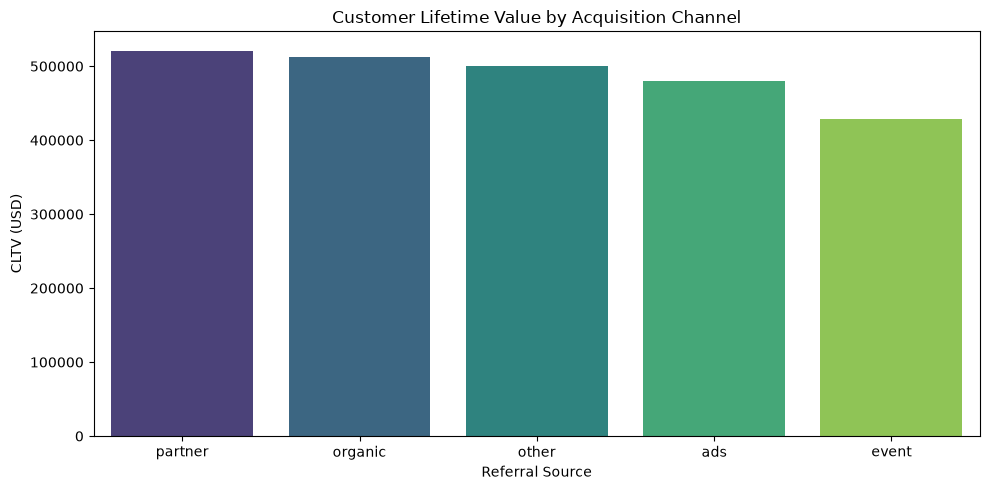

In [9]:
plt.figure(figsize=(10,5))
sns.barplot(data=cltv_table, x='referral_source', y='cltv', palette='viridis')
plt.title('Customer Lifetime Value by Acquisition Channel')
plt.xlabel('Referral Source')
plt.ylabel('CLTV (USD)')
plt.tight_layout()
plt.savefig(r'C:\Users\SATYA\OneDrive\Desktop\using-datasets-week3-work\cltv_by_channel.png', dpi=150)
plt.show()

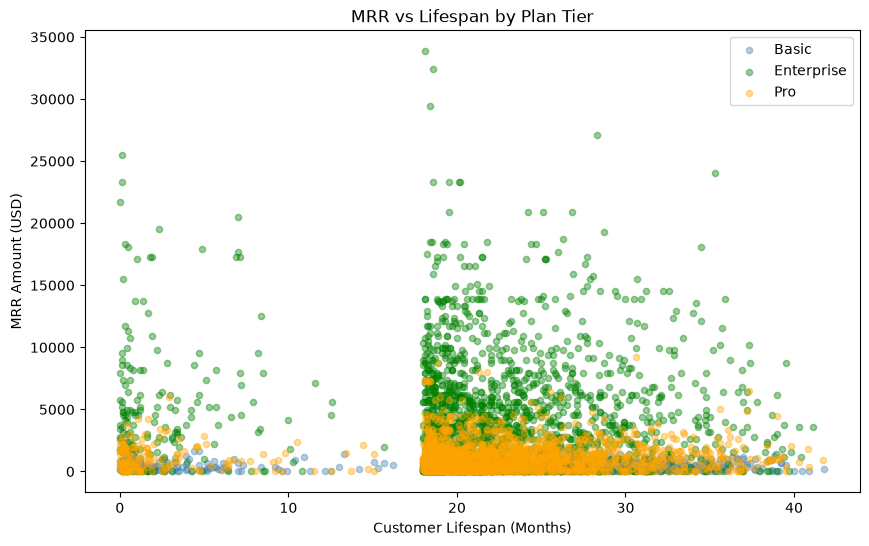

In [10]:
plt.figure(figsize=(10,6))
colors = {'Basic':'steelblue','Pro':'orange','Enterprise':'green'}
for tier, group in df.groupby('plan_tier'):
    plt.scatter(group['lifespan_months'], group['mrr_amount'], 
                label=tier, alpha=0.4, s=20, color=colors[tier])
plt.xlabel('Customer Lifespan (Months)')
plt.ylabel('MRR Amount (USD)')
plt.title('MRR vs Lifespan by Plan Tier')
plt.legend()
plt.savefig(r'C:\Users\SATYA\OneDrive\Desktop\using-datasets-week3-work\cltv_by_channel.png', dpi=150)
plt.show()

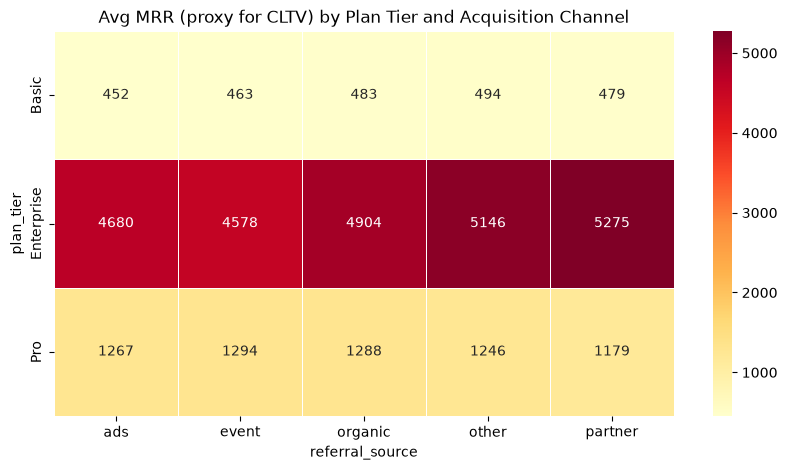

In [11]:
# Pivot table
pivot = df.groupby(['plan_tier','referral_source'])['mrr_amount'].mean().unstack()

plt.figure(figsize=(10,5))
sns.heatmap(pivot, annot=True, fmt='.0f', cmap='YlOrRd', linewidths=0.5)
plt.title('Avg MRR (proxy for CLTV) by Plan Tier and Acquisition Channel')
plt.savefig(r'C:\Users\SATYA\OneDrive\Desktop\using-datasets-week3-work\cltv_by_channel.png', dpi=150)
plt.show()

In [12]:
# ---- Export CLTV analysis results to CSV ----

# 1. CLTV by acquisition channel
cltv_table.round(2).to_csv(f'{BASE}/cltv_by_channel.csv', index=False)

# 2. CLTV by plan tier
cltv_by_tier.round(2).to_csv(f'{BASE}/cltv_by_plan_tier.csv')

# 3. Account-level CLTV with segment labels
account_cltv.round(2).to_csv(f'{BASE}/account_level_cltv.csv', index=False)

print("Exported 3 CSV files to:", BASE)
print(" - cltv_by_channel.csv     ", cltv_table.shape)
print(" - cltv_by_plan_tier.csv   ", cltv_by_tier.shape)
print(" - account_level_cltv.csv  ", account_cltv.shape)

Exported 3 CSV files to: C:\Users\SATYA\OneDrive\Desktop\using-datasets-week3-work
 - cltv_by_channel.csv      (5, 5)
 - cltv_by_plan_tier.csv    (3, 4)
 - account_level_cltv.csv   (500, 5)
